# Homework 6 : Autoencoders, Diffusion Models, and GANs

In this assignment, we will explore three fundamental approaches to generative modeling:
- **Autoencoders**: Learning compressed representations through reconstruction
- **Diffusion Models**: Generating data by learning to reverse a noising process
- **Generative Adversarial Networks (GANs)**: Learning through adversarial training

We'll implement each from scratch and compare their strengths, weaknesses, and internal representations.

## Setup

You are encouraged to use a GPU when training your diffusion and GAN models as these are fairly parameter intensive. In order to do so, you should

1. Navigate to `Runtime → Change runtime type`
2. Set `Hardware accelerator: GPU` (preferably T4 or better)
3. Click Save

However, do be warned that there are usage limits. If you're not doing anything compute heavy, we reccomend using CPU whenever you can!

**NOTE: YOU WILL WANT TO SAVE PERIODICALLY SINCE GOOGLE COLAB DOES NOT RETAIN RUNTIME INFORMATION ACROSS SESSIONS, SO YOU WILL NEED TO RERUN THE IMPORT AND DATA CELLS, AS WELL AS ANY RELEVANT CELLS ANYTIME YOUR RUNTIME SWITCHES!**

In [ ]:
# Install any missing packages (for Colab)
!pip install -q matplotlib numpy torch torchvision scikit-learn Pillow tqdm torchinfo

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import IPython.display
from sklearn.manifold import TSNE
from tqdm import tqdm
import io
import os

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.10.0+cpu
Device: cpu


## Introduction
Autoencoders are really cool. They use this architecture of encoder + decoder to learn data representation in an unsupervised manner. Sounds complicated? Let's break it down.

![Autoencoders](https://drive.google.com/uc?export=view&id=18iU9_yZfqs2QlTPbaibzkMtdIekLuPj2)

As we can see, the autoencoder is divided roughly in two parts:
- The **encoder** that encodes the input to a "code" (internal representation) with reduced dimensions. Maps input $x$ to latent representation $z = E(x)$
- The **decoder** that decodes the "code" to an output that is the same dimensions as the input. Reconstructs input from latent code $\hat{x} = D(z) = D(E(x))$

The autoencoder tries to learn a function $h(x) \approx x$, or to approximate the identity function to output $h(x) = x'$ that is similar to $x$.

The objective is to minimize reconstruction error:
$$\mathbb{L}_{\text{recon}} = \mathbb{E}_{x \sim p_{\text{data}}}[\|x - D(E(x))\|^2]$$

This may sound like a pretty trivial task, so why not just use the identity function? Well, it's impossible to find a perfect representation of the identity function since we reduced dimensionality of the input into the code during the encoding part, and try to "reconstruct" the original image using only the dimensionally reduced code.

E.x. Given an input of a 10x10 image, and a hidden size of 50, the encoder is forced to learn a compressed representation of the image (from 100 units to 50 units). This encoding is almost always lossy, but the point is that we train the encoder to recognize important structures in the input and throw away the unimportant noise.

## Transposed Convolutions

Conceptually, transposed-convolution reverses the effects of convolution, also known as a deconvolution. Convolution with a stride of larger than 1 reduces the size of the input, while transposed-convolution can be described as a "fractional stride" convolution, it upscales the size of the input. Here's a visualisation.

**Regular Convolution**: Reduces spatial dimensions
- Input: $H \times W$
- Output: $\frac{H}{s} \times \frac{W}{s}$ (where $s$ is stride)

**Transposed Convolution**: Increases spatial dimensions
- Input: $H \times W$  
- Output: $s \cdot H \times s \cdot W$

This "upsampling" operation is crucial for the decoder to reconstruct full-sized images from compressed representations. We can see this expressed visually below.

#### Convolution with stride = 2 *going from bigger to smaller*:
![convolution.gif](https://drive.google.com/uc?export=view&id=1TjSgMinNQ629TrdEmcVjKuwWZ9MGMfg7)

#### Transposed-Convolution (convolution with fractional stride) *going from smaller to bigger*:
![deconvolution.gif](https://drive.google.com/uc?export=view&id=1opzIaiShA5_nLT5Y5Kh_GqPT9IlVeQF5)

As we can see, transposed-convolution upscales the input. This is important for our decoder as its job is to upscale the encoded and compressed internal representation to its original size.

In PyTorch you can perform this operation using [`nn.ConvTranspose2d`](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), which works similarly to `nn.Conv2d` but increases spatial dimensions. Alternatively, a common modern approach is to use [`nn.Upsample`](https://pytorch.org/docs/stable/generated/torch.nn.Upsample.html) followed by a regular `nn.Conv2d`, which avoids checkerboard artifacts.

> **⚠️ PyTorch vs TensorFlow convention**: PyTorch uses **channels-first** format `(N, C, H, W)`, whereas TensorFlow uses channels-last `(N, H, W, C)`. This affects how you index into tensors and how you define convolutional layers — you must always specify `in_channels` explicitly in PyTorch.

## Data Loading and Preprocessing

Let's first load in the data we are going to need for this assignment. For our simple example, we are going to load in the MNIST data once again!

**NOTES:**
- We won't really be using the labels in the optimization pipeline, so we don't need to one-hot encode them.
- In PyTorch, image tensors are stored as `(N, C, H, W)` — channels come **before** spatial dimensions.

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.82MB/s]


Training data shape: torch.Size([60000, 1, 32, 32])
Test data shape:     torch.Size([10000, 1, 32, 32])
Value range: [0.00, 1.00]


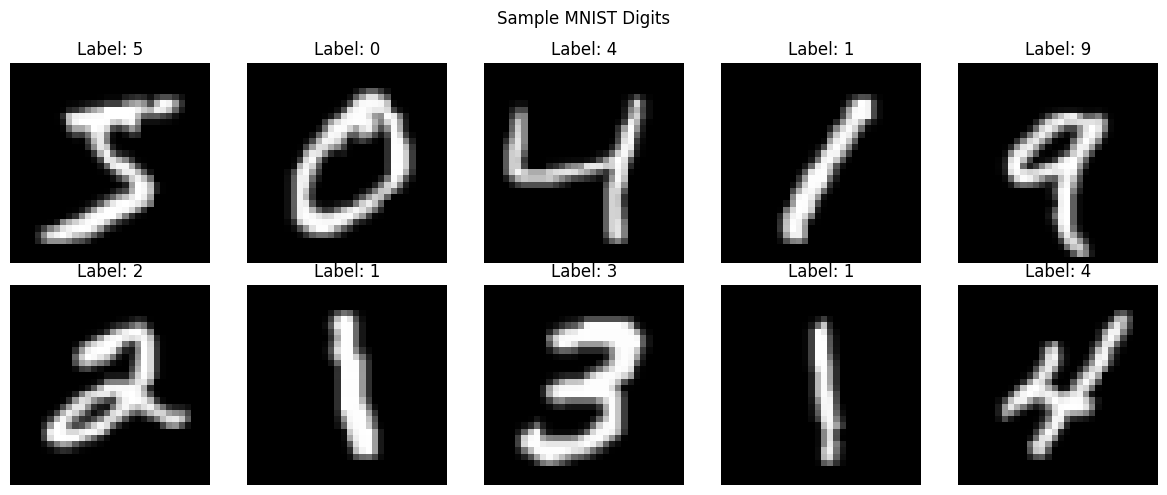

In [3]:
# Load MNIST dataset using torchvision
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True)

def prepare_data(dataset):
    """Normalize to [0,1], add channel dim, and resize to 32x32. Returns (N,1,32,32)."""
    data   = dataset.data.float() / 255.0           # (N, 28, 28)
    data   = data.unsqueeze(1)                       # (N, 1, 28, 28)
    data   = F.interpolate(data, size=(32, 32), mode='bilinear', align_corners=False)
    labels = dataset.targets
    return data, labels

X_train, Y_train = prepare_data(train_dataset)
X_test,  Y_test  = prepare_data(test_dataset)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape:     {X_test.shape}")
print(f"Value range: [{X_train.min():.2f}, {X_train.max():.2f}]")

# Visualize some samples
# Note: PyTorch tensors are (N, C, H, W), so we index channel 0 with img[0]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i, 0], cmap='gray')   # img[channel]
    ax.set_title(f"Label: {Y_train[i].item()}")
    ax.axis('off')
plt.suptitle("Sample MNIST Digits")
plt.tight_layout()
plt.show()

### Implementing The Auto-Encoder

Below, we are going to ask for you to go ahead and implement the autoencoder.

The basic structure of an auto-encoder has already been discussed previously and shouldn't come as a surprise:

Learn a hypothesis function $h(x) = h_{decoder}(h_{encoder}(x))$ such that $h(x) \sim x$.

Below, go ahead and finish the autoencoder implementation.

- Implement the autoencoder `forward()` method.
- Implement the encoder and decoder architectures with a nice bottleneck.

**NOTES:**
- Consider what is reasonable for the encoder/decoder layers. We're going from a 1-channel 32×32 input to a latent encoding and back, so extreme channel counts in the hundreds might not be useful.
- Your input and output spatial dimensions must match. MNIST images are powers of 2, so strided convolutions can halve/double dimensions cleanly.
- **In PyTorch, `nn.Conv2d` requires you to specify `in_channels` explicitly**, unlike Keras which infers them. Plan your channel sizes at each stage before you start coding.
- If you are confused on the general architecture, review the lecture slides. Pay attention to how sizes change at each layer.

## **[TODO] Building the Autoencoder**

Our autoencoder architecture is as follows:
- **Encoder**: Compresses the image features into a smaller latent space. Think about how strided convolutions can progressively reduce spatial dimensions while increasing channels.
- **Decoder**: Reconstructs the input from the latent space. This should be the inverse of your encoder — what PyTorch layers expand spatial dimensions back up?

Now it is your job to fill out the corresponding TODOs in the block below!

In [4]:
import torch.nn as nn
from torchinfo import summary

class Autoencoder(nn.Module):
    """
    Convolutional Autoencoder for MNIST.

    Architecture:
    - Encoder: Compresses (1, 32, 32) → small latent feature map
    - Decoder: Reconstructs latent → (1, 32, 32)

    Note: PyTorch tensors are (N, C, H, W) — channels first!
    """

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        """
        Forward pass: encode then decode.
        In PyTorch we override forward(), not call().
        """
        encoded_x = self.encoder(x)
        decoded_x = self.decoder(encoded_x)
        return decoded_x


# TODO: Define encoder architecture using nn.Sequential
# Useful layers: nn.Conv2d, nn.BatchNorm2d, nn.ReLU, nn.LeakyReLU
#
# nn.Conv2d(in_channels, out_channels, kernel_size, stride=..., padding=...)
# stride=2 halves spatial dimensions; padding=1 with kernel=3 keeps dims clean.
#
# Input shape: (N, 1, 32, 32)
encoder = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),   # → (N, 16, 16, 16)
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # → (N, 32, 8, 8)
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # → (N, 64, 4, 4)
    nn.BatchNorm2d(64),
    nn.ReLU(),
)

decoder = nn.Sequential(
    nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # → (N, 32, 8, 8)
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # → (N, 16, 16, 16)
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),   # → (N, 1, 32, 32)
    nn.Sigmoid(),  # Required — BCELoss expects outputs in (0, 1)
)

# Create and inspect the autoencoder
autoencoder = Autoencoder(encoder, decoder).to(device)
summary(autoencoder, input_size=(1, 1, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [1, 1, 32, 32]            --
├─Sequential: 1-1                        [1, 64, 4, 4]             --
│    └─Conv2d: 2-1                       [1, 16, 16, 16]           160
│    └─BatchNorm2d: 2-2                  [1, 16, 16, 16]           32
│    └─ReLU: 2-3                         [1, 16, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 32, 8, 8]             4,640
│    └─BatchNorm2d: 2-5                  [1, 32, 8, 8]             64
│    └─ReLU: 2-6                         [1, 32, 8, 8]             --
│    └─Conv2d: 2-7                       [1, 64, 4, 4]             18,496
│    └─BatchNorm2d: 2-8                  [1, 64, 4, 4]             128
│    └─ReLU: 2-9                         [1, 64, 4, 4]             --
├─Sequential: 1-2                        [1, 1, 32, 32]            --
│    └─ConvTranspose2d: 2-10             [1, 32, 8, 8]             32,800
│ 

### Making A Visualization Routine

We'd like to see how training is progressing after each epoch. In TensorFlow/Keras this was done via `Callback` objects that plug into `model.fit()`. In PyTorch we write a **manual training loop**, so we call visualization logic directly at the end of each epoch.

The `ImageVisualizer` class below stores one frame per epoch and can save them as a GIF. We call `visualizer.on_epoch_end(model, epoch)` ourselves inside the training loop — no magic infrastructure required.

In [5]:
#@title ImageVisualizer for Autoencoder

#hidden

#@markdown You don't really have to look at it, so just run the block with the play button.

#@markdown * If you open up the code, double-click the right side of the cell to hide it again

class ImageVisualizer:
    def __init__(self, sample_inputs):
        """sample_inputs: tensor of shape (N, 1, 32, 32)"""
        self.sample_inputs = sample_inputs.to(device)
        self.imgs = []

    def on_epoch_end(self, model, epoch):
        model.eval()
        with torch.no_grad():
            encoding   = model.encoder(self.sample_inputs)
            prediction = model.decoder(encoding)
            # Upsample first channel of encoding to 32x32 for side-by-side display
            enc_pic = F.interpolate(encoding[:, :1], size=(32, 32),
                                    mode='bicubic', align_corners=False)
        outputs = torch.cat([self.sample_inputs, enc_pic, prediction], dim=0)
        self.add_to_imgs(outputs, epoch)
        model.train()

    def add_to_imgs(self, outputs, epoch, nrows=3, ncols=8, figsize=(18, 8)):
        fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        axs[0][0].set_title(f'Epoch {epoch+1}')
        axs[0][3].set_title('Inputs')
        axs[1][3].set_title('Encoding')
        axs[1][4].set_title('(Channel 0, upscaled)')
        axs[2][3].set_title('Decoding')
        for i, ax in enumerate(axs.reshape(-1)):
            # Tensors are (C, H, W) — take channel 0 for grayscale display
            ax.imshow(outputs[i, 0].cpu().numpy(), cmap='gray')
            ax.axis('off')
        self.imgs.append(self.fig2img(fig))
        plt.close(fig)

    @staticmethod
    def fig2img(fig):
        buf = io.BytesIO()
        fig.savefig(buf)
        buf.seek(0)
        return Image.open(buf).copy()   # .copy() detaches from the file handle

    def save_gif(self, filename='mnist_recon', loop=True, duration=500):
        self.imgs[0].save(
            filename + '.gif', save_all=True, append_images=self.imgs[1:],
            loop=loop, duration=duration)

### Actually Training The Model!

Finally, it's time to actually train the model! Hurray!

However, let's talk about loss first!

## Understanding Reconstruction Loss: Balancing MSE and BCE

When training an autoencoder on image data, we must choose an appropriate reconstruction loss function. Two common choices are Mean Squared Error (MSE) and Binary Cross-Entropy (BCE). Understanding when and why to use each is crucial for achieving good reconstruction quality.

Mean Squared Error measures the squared difference between predicted and actual pixel values:

$$L_{MSE} = \frac{1}{n}\sum_{i=1}^{n}(x_i - \hat{x}_i)^2$$

MSE treats pixel intensities as continuous values and penalizes larger errors quadratically. This makes it sensitive to outliers and particularly effective when we care about preserving precise intensity values. The gradient of MSE is proportional to the error magnitude, providing stronger gradients for pixels that are far from their target values.

Binary Cross-Entropy, on the other hand, treats each pixel as an independent Bernoulli variable:

$$L_{BCE} = -\frac{1}{n}\sum_{i=1}^{n}[x_i \log(\hat{x}_i) + (1-x_i)\log(1-\hat{x}_i)]$$

BCE is derived from maximum likelihood estimation under a Bernoulli noise model. It provides stronger gradients when predictions are confidently wrong (close to 0 or 1 when they should be the opposite) and weaker gradients when predictions are already close to correct. This makes BCE particularly effective for binary or near-binary images where pixels are mostly black or white.

For MNIST digits, which contain significant amounts of white background (pixel value ≈ 1) and dark strokes (pixel value ≈ 0), we can benefit from combining both losses:

$$L_{total} = \alpha \cdot L_{MSE} + \beta \cdot L_{BCE}$$

The MSE component helps preserve smooth intensity gradients, while the BCE component provides strong signal for getting the binary structure correct.

### `CombinedLoss` class.

Why don't you try implementing this now!

**NOTES:**
 - In PyTorch, custom loss functions subclass [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) and implement `forward(pred, target)`.
   - Note the argument order: **prediction first, target second** — the opposite of Keras.
 - Useful built-ins: [`nn.MSELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) and [`nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html).
   - `nn.BCELoss` expects predictions in `(0, 1)` — make sure your decoder uses a sigmoid activation!
 - You may have to tune the learning rate!

In [6]:
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5):
        super().__init__()
        self.alpha    = alpha
        self.beta     = beta
        self.mse_loss = nn.MSELoss()
        self.bce_loss = nn.BCELoss()

    def forward(self, y_pred, y_true):
        """
        Compute combined MSE + BCE loss.

        Args:
            y_pred: Model predictions (must be in (0,1) for BCE)
            y_true: Ground truth targets
        Note: PyTorch convention is (pred, target), opposite of Keras.
        """
        mse      = self.mse_loss(y_pred, y_true)
        bce      = self.bce_loss(y_pred, y_true)
        combined = self.alpha * mse + self.beta * bce
        return combined

mse_bce_loss = CombinedLoss(alpha=0.5, beta=0.5)

We will train the autoencoder for several epochs, monitoring the reconstruction loss. During training, the encoder learns to identify and preserve the most important features of the digits, while the decoder learns to reconstruct realistic digits from these compressed representations.

### [TODO] Fill in the missing components in the following cell block

Unlike Keras, PyTorch does not have a built-in `model.compile()` / `model.fit()`. Instead, we write an explicit training loop:
1. **Forward pass**: compute predictions
2. **Compute loss**
3. **Backward pass**: `loss.backward()` computes gradients
4. **Optimizer step**: `optimizer.step()` updates weights
5. **Zero gradients**: `optimizer.zero_grad()` before the next batch

- You can get really good performance without many epochs.
- Consider removing the dataset slice if you want to train on more data!

Epoch 1/10 — Train: 0.2734  Val: 0.1746
Epoch 2/10 — Train: 0.1328  Val: 0.1042
Epoch 3/10 — Train: 0.0912  Val: 0.0792
Epoch 4/10 — Train: 0.0745  Val: 0.0684
Epoch 5/10 — Train: 0.0660  Val: 0.0620
Epoch 6/10 — Train: 0.0612  Val: 0.0587
Epoch 7/10 — Train: 0.0588  Val: 0.0571
Epoch 8/10 — Train: 0.0567  Val: 0.0547
Epoch 9/10 — Train: 0.0554  Val: 0.0542
Epoch 10/10 — Train: 0.0546  Val: 0.0531


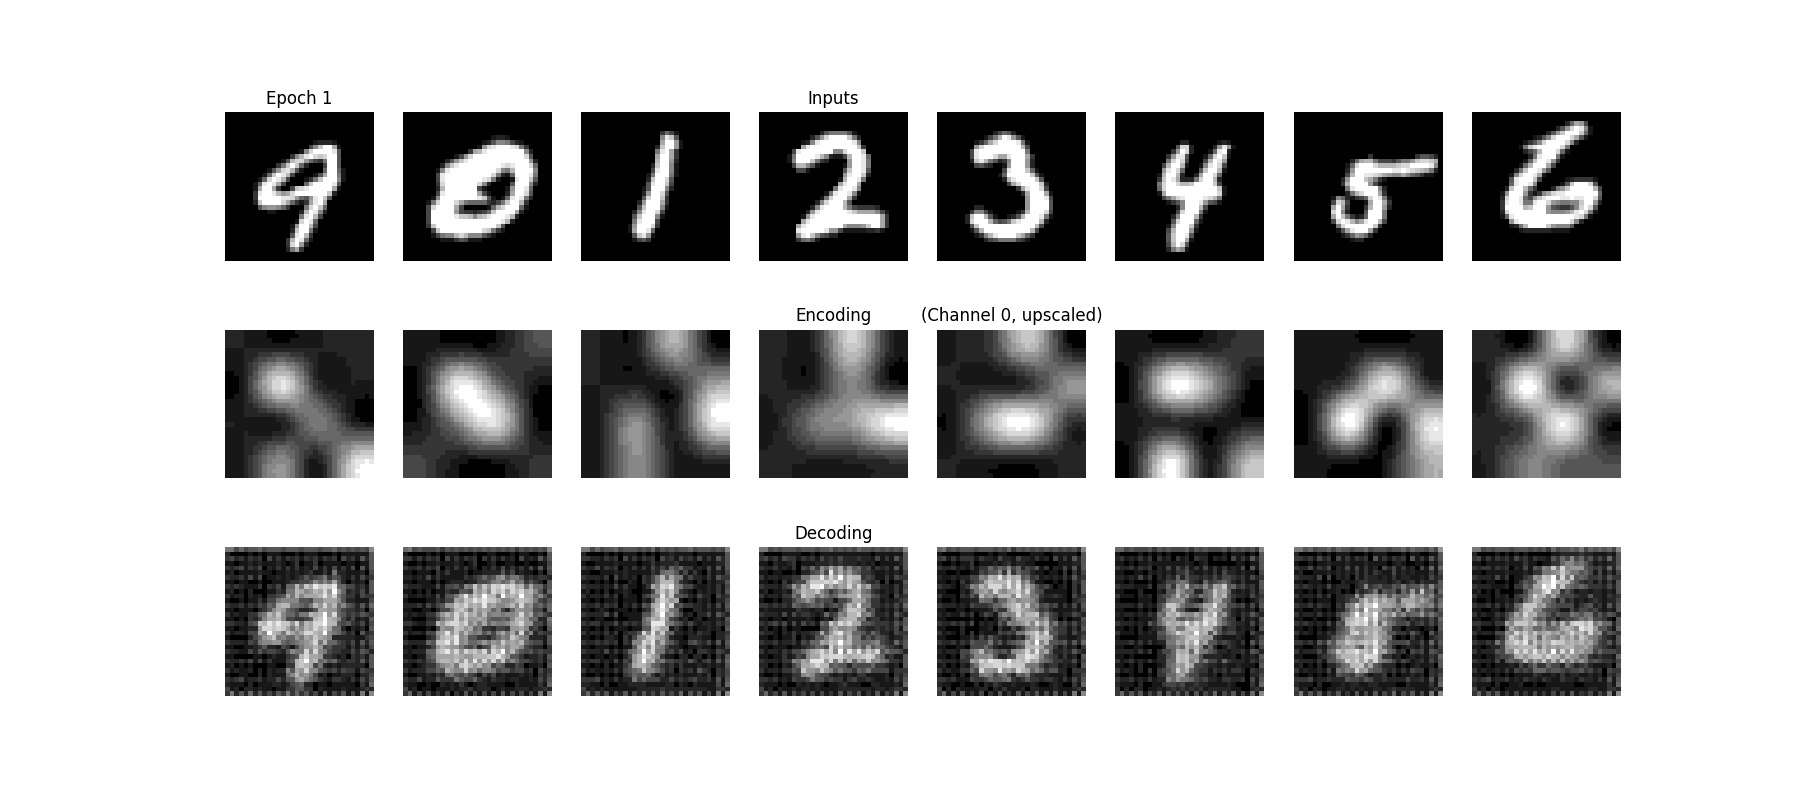

In [7]:
# Select test samples for visualization
test_samples = X_test[-8:].to(device)

# Re-instantiate the model
autoencoder = Autoencoder(encoder, decoder).to(device)

# Create visualization helper
viz_callback = ImageVisualizer(test_samples)

# TODO: Choose your optimizer
# e.g. torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = mse_bce_loss

optimizer  = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
NUM_EPOCHS = 10      # Even 5 shows visible convergence on the 5k subset
BATCH_SIZE = 128

# Build DataLoaders (PyTorch's equivalent of tf.data.Dataset)
# Think about why we pass the same tensor as both input and target
train_loader = DataLoader(TensorDataset(X_train[:5000]), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_test[:1000]),  batch_size=BATCH_SIZE)

train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    # ── Training ──────────────────────────────────────────────────────────
    autoencoder.train()
    batch_losses = []
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()           # clear gradients from last step
        x_recon = autoencoder(x_batch)  # forward pass
        loss    = criterion(x_recon, x_batch)
        loss.backward()                 # compute gradients
        optimizer.step()                # update weights
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    # ── Validation ────────────────────────────────────────────────────────
    autoencoder.eval()
    val_batch_losses = []
    with torch.no_grad():               # no gradient tracking during eval
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            x_recon = autoencoder(x_batch)
            val_batch_losses.append(criterion(x_recon, x_batch).item())

    val_loss = np.mean(val_batch_losses)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Train: {train_loss:.4f}  Val: {val_loss:.4f}")
    viz_callback.on_epoch_end(autoencoder, epoch)

# Save and display the training animation
viz_callback.save_gif('autoencoder_training')
IPython.display.Image(open('autoencoder_training.gif', 'rb').read())

### Training Analysis

So what's actually happening during training? As the model trains, the encoder learns to extract important features from digits. Simultaneously, the decoder learns to reconstruct digits from these features and reconstruction quality improves as the model finds better latent representations which is why we have a balanced loss function. Over time, the latent space becomes more structured and meaningful.

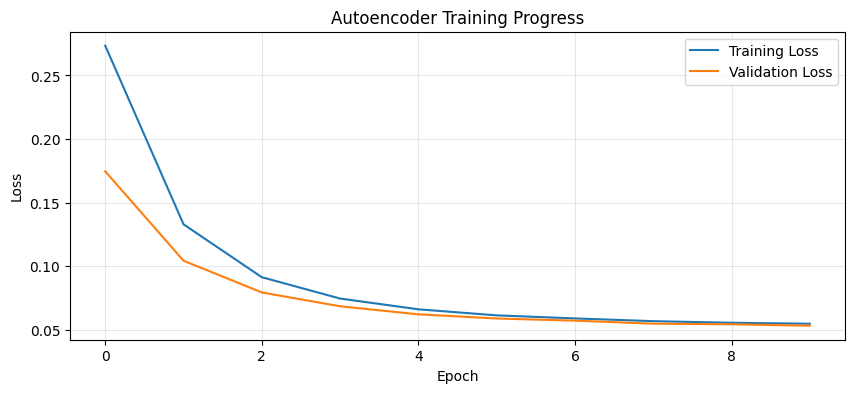

In [8]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# Part 2: Diffusion Models

## Introduction to Diffusion Models

Diffusion models generate data by learning to reverse a gradual noising process. They've recently achieved state-of-the-art results in image generation (DALL-E 2, Stable Diffusion, Midjourney).

Diffusion models represent a fundamental shift in how we think about generative modeling. While autoencoders learn to compress and reconstruct, and GANs learn to generate through adversarial training, diffusion models learn to generate by reversing a corruption process. The core insight is if we can learn to remove small amounts of noise, we can chain these denoising steps together to progressively transform pure noise into structured data.

The mathematical framework consists of two processes. The forward process gradually adds Gaussian noise to data over T timesteps until it becomes indistinguishable from pure noise. The reverse process, which we must learn, inverts this corruption by iteratively removing noise to recover clean data. This approach has several advantages: the forward process requires no learning, and the reverse process can be trained with a simple denoising objective that is often more stable than GAN training.

## The Forward Diffusion Process

The forward process defines how we progressively corrupt data by adding Gaussian noise. Starting with a clean image $x_0$ from our dataset, we create a sequence of increasingly noisy versions $x_1, x_2, ..., x_T$ where $x_T$ is essentially pure Gaussian noise.

At each timestep $t$, we add a small amount of Gaussian noise to the previous state:

$$q(x_t | x_{t-1}) = N(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t I)$$

where $\beta_t$ is a variance schedule that controls how much noise is added at timestep $t$. The schedule typically increases over time, adding more noise in later steps. The mean $\sqrt{1-\beta_t}x_{t-1}$ ensures that we retain some information from the previous timestep while the variance $\beta_t I$ adds new noise.

A key mathematical property of Gaussian diffusion is that we can sample $x_t$ directly from $x_0$ without computing all intermediate steps. If we define $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$, then using the reparameterization trick we can jump directly to any timestep:

$$x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon, \quad \epsilon \sim N(0, I)$$

Where:
- $\alpha_t = 1 - \beta_t$
- $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ (cumulative product)
- $\epsilon \sim N(0, I)$: Random noise

The term $\sqrt{\bar{\alpha}_t}$ controls how much of the original signal remains, while $\sqrt{1-\bar{\alpha}_t}$ controls the noise magnitude. As $t \rightarrow T$, $\bar{\alpha}_t \rightarrow 0$, meaning $x_T$ approaches pure Gaussian noise.

### [TODO] Implementing the Forward Noising

It is now your turn to implement the equation
$$x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon$$

You are responsible for filling in `__init__` and `add_noise`. Think about what values can be precomputed from the information available from the `__init__` parameters.

In [9]:
class DiffusionForwardProcess:
    """
    Implements the forward noising process of diffusion models.

    The forward process gradually adds Gaussian noise to data according to
    a variance schedule. This is a plain Python class, not an nn.Module,
    since it has no learnable parameters.
    """

    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02):
      self.num_timesteps = num_timesteps
      self.betas = np.linspace(beta_start, beta_end, num_timesteps)

      # α_t = 1 - β_t
      self.alphas = 1.0 - self.betas

      # ᾱ_t = ∏ α_s  (cumulative product)
      self.alphas_cumprod = np.cumprod(self.alphas)

      # Precompute the two square-root terms used in add_noise
      self.sqrt_alphas_cumprod          = np.sqrt(self.alphas_cumprod)
      self.sqrt_one_minus_alphas_cumprod = np.sqrt(1.0 - self.alphas_cumprod)

    def add_noise(self, x_0, t, noise=None):
        """
        Add noise using the direct sampling formula:
        x_t = √(ᾱ_t) * x_0 + √(1 - ᾱ_t) * ε

        Args:
            x_0:   Clean images, shape (batch, C, H, W)  ← channels first in PyTorch!
            t:     Timesteps, shape (batch,) — torch.LongTensor
            noise: Optional pre-generated noise for reproducibility

        Returns:
            x_t:   Noisy images at timestep t
            noise: The noise that was added
        """
        if noise is None:
            noise = torch.randn_like(x_0)   # same shape & device as x_0

        # Index precomputed values with t; convert to float32 on the right device
        sqrt_alpha_cumprod_t = torch.tensor(
            self.sqrt_alphas_cumprod[t.cpu().numpy()], dtype=torch.float32
        ).to(x_0.device)
        sqrt_one_minus_alpha_cumprod_t = torch.tensor(
            self.sqrt_one_minus_alphas_cumprod[t.cpu().numpy()], dtype=torch.float32
        ).to(x_0.device)

        # Reshape for broadcasting: (batch,) → (batch, 1, 1, 1)  [channels-first NCHW]
        sqrt_alpha_cumprod_t           = sqrt_alpha_cumprod_t.view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alpha_cumprod_t.view(-1, 1, 1, 1)

        x_t = sqrt_alpha_cumprod_t * x_0 + sqrt_one_minus_alpha_cumprod_t * noise
        return x_t, noise

forward_process = DiffusionForwardProcess()

## Visualizing the Forward Process

Let's see how an image gradually becomes noise:

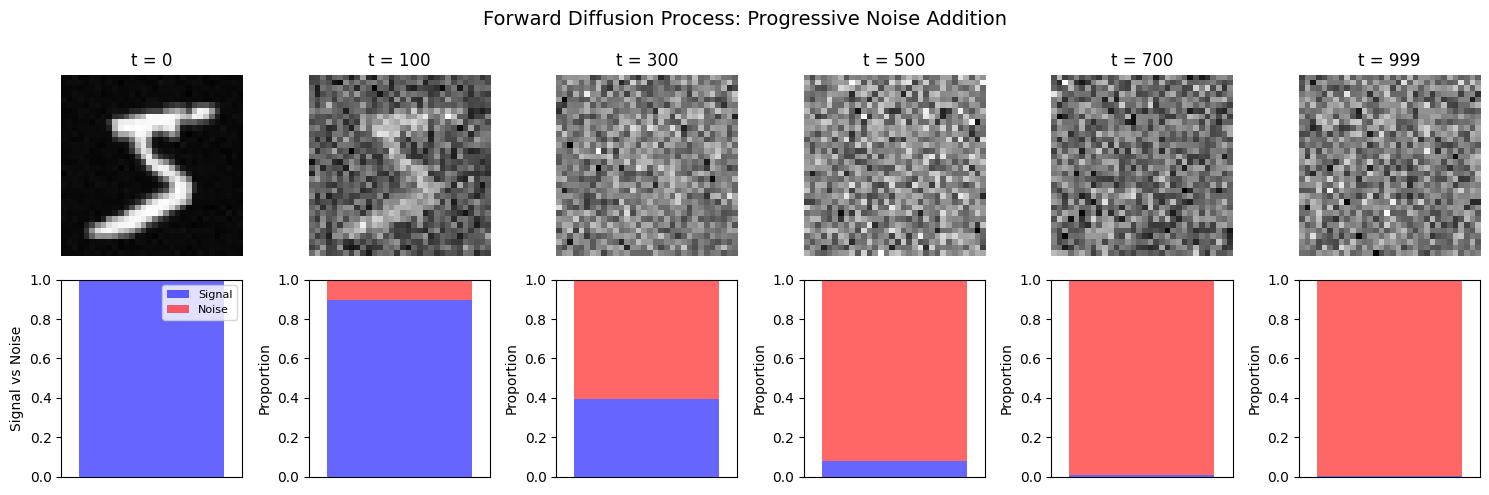

In [10]:
#@title Visualizer for Forward Diffusion Process

#@markdown You don't really have to look at it, so just run the block with the play button.

#@markdown * If you open up the code, double-click the right side of the cell to hide it again

sample_image = X_train[0:1].to(device)
timesteps_to_show = [0, 100, 300, 500, 700, 999]

fig, axes = plt.subplots(2, len(timesteps_to_show), figsize=(15, 5))

for i, t in enumerate(timesteps_to_show):
    t_tensor    = torch.tensor([t], dtype=torch.long)
    noised_image, _ = forward_process.add_noise(sample_image.cpu(), t_tensor)

    # PyTorch: tensor is (N, C, H, W) → display channel 0 with [0, 0]
    axes[0, i].imshow(noised_image[0, 0].cpu().numpy(), cmap='gray')
    axes[0, i].set_title(f't = {t}')
    axes[0, i].axis('off')

    alpha_bar = forward_process.alphas_cumprod[t]
    axes[1, i].bar([0], [alpha_bar],   color='blue', alpha=0.6, label='Signal')
    axes[1, i].bar([0], [1-alpha_bar], bottom=[alpha_bar], color='red', alpha=0.6, label='Noise')
    axes[1, i].set_ylim([0, 1])
    axes[1, i].set_xlim([-0.5, 0.5])
    axes[1, i].set_xticks([])
    axes[1, i].set_ylabel('Proportion')
    if i == 0:
        axes[1, i].legend(loc='upper right', fontsize=8)

axes[0, 0].set_ylabel('Noised Image',    fontsize=10)
axes[1, 0].set_ylabel('Signal vs Noise', fontsize=10)
plt.suptitle('Forward Diffusion Process: Progressive Noise Addition', fontsize=14)
plt.tight_layout()
plt.show()

## The Reverse Process: Learning to Denoise

The reverse process is where we learn to generate new samples. Given a noisy image $x_t$, we want to predict a slightly less noisy version $x_{t-1}$. If we can do this repeatedly, we can start from pure noise $x_T \sim N(0, I)$ and gradually denoise it to produce a clean sample $x_0$.

The reverse process is modeled as:

$$p_\theta(x_{t-1} | x_t) = N(x_{t-1}; \mu_\theta(x_t, t), \sigma_t^2 I)$$

where $\mu_\theta$ is a neural network that predicts the mean of the denoised distribution. In practice, instead of directly predicting $\mu_\theta$, we train a neural network $\epsilon_\theta(x_t, t)$ to predict the noise $\epsilon$ that was added to create $x_t$. This is equivalent but often trains more stably.

This makes our training objective fairly simple. We sample a clean image $x_0$, sample a random timestep $t$, add noise to get $x_t$, and train the network to predict that noise:

$$L_{simple} = \mathbb{E}_{x_0, \epsilon, t}[\|\epsilon - \epsilon_\theta(x_t, t)\|^2]$$

This is just mean squared error between the true noise and predicted noise. Once trained, we can generate samples using the sampling equation:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t, t)\right) + \sigma_t z$$

where $z \sim N(0, I)$ except for the final step where we set $z = 0$ for deterministic output.

## Building the Denoising Network (U-Net)

A U-Net is a convolutional neural network with a distinctive U-shaped architecture consisting of two paths: a contracting encoder that progressively downsamples the input to capture high-level semantic features, and an expanding decoder that upsamples back to the original resolution. The key innovation is skip connections that directly link corresponding encoder and decoder layers, allowing fine-grained spatial information to bypass the bottleneck.

In diffusion models, we need to predict and remove noise from images at various noise levels. This is fundamentally a denoising task that requires two capabilities:

1. Understanding what's in the image — the semantic context — which is the encoder's job
2. Preserving spatial localization — knowing where things are — through skip connections

The skip connections are what make U-Nets special. Without shortcuts from encoder to decoder, spatial details would be lost in the bottleneck compression. The skip connections let the model access both the "what" from deeper layers and the "where" from shallower layers simultaneously.

#### Time Embedding

The time embedding tells the model how much noise is present in the current image. This is critical because the optimal denoising strategy changes dramatically across the diffusion process: at early timesteps with high noise, the model needs to recover basic structure; at late timesteps with low noise, it refines fine details. We have written this for you :)

In [11]:
def get_time_embedding(timesteps, embedding_dim=32):
    """
    Create sinusoidal time embeddings.
    This helps the network understand which timestep it's denoising.

    Following the Transformer positional encoding:
    PE(t, 2i)   = sin(t / 10000^(2i/d))
    PE(t, 2i+1) = cos(t / 10000^(2i/d))

    Args:
        timesteps:     LongTensor of shape (batch,)
        embedding_dim: Dimension of the output embedding

    Returns:
        Embedding tensor of shape (batch, embedding_dim)
    """
    half_dim  = embedding_dim // 2
    emb       = np.log(10000.0) / (half_dim - 1)
    emb       = torch.exp(torch.arange(half_dim, dtype=torch.float32) * -emb)

    timesteps = timesteps.float()
    emb       = timesteps[:, None] * emb[None, :]                 # (batch, half_dim)
    emb       = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)  # (batch, embedding_dim)
    return emb

### [TODO] Define your UNet Architecture Below

We walk you through some of the finer details through the TODOs so pay attention ;)

1. First fill out `forward_conv_block(in_channels, filters)` — the encoder block that downsamples by 2×
2. Fill out `reverse_conv_block(in_channels, filters)` — the decoder block that upsamples by 2×
3. Fill out `__init__` to define all model components
4. Fill out `forward(x, t)` to define the forward pass with skip connections

**Important PyTorch note**: Unlike Keras, `nn.Conv2d` requires you to specify `in_channels` explicitly. Plan your channel counts at each stage before writing code. As a hint, here's the expected data flow:

```
Input:       (N,  1, 32, 32)
enc1 out:    (N, bf, 16, 16)   ← stride-2 conv, bf = base_filters
enc2 out:    (N, 2bf, 8,  8)
enc3 out:    (N, 4bf, 4,  4)
bottleneck:  (N, 8bf, 4,  4)   ← no downsampling
dec1 in:     (N, 12bf, 4, 4)   ← cat(bottleneck, enc3), then upsample
dec1 out:    (N, 4bf, 8,  8)
dec2 in:     (N, 6bf, 8,  8)   ← cat(dec1, enc2), then upsample
dec2 out:    (N, 2bf, 16, 16)
dec3 in:     (N, 3bf, 16, 16)  ← cat(dec2, enc1), then upsample
dec3 out:    (N, bf, 32, 32)
Output:      (N,  1, 32, 32)   ← 1×1 conv
```

In [ ]:
class DiffusionUNet(nn.Module):
    """
    U-Net architecture for diffusion models.

    The U-Net is perfect for diffusion models because:
    1. Skip connections preserve spatial details lost during downsampling
    2. The bottleneck learns high-level semantic features
    3. Time conditioning at each stage allows timestep-aware denoising
    """

    def __init__(self, img_size=32, base_filters=64, time_emb_dim=32):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        bf = base_filters

        # ========== TIME EMBEDDING NETWORK ==========
        # TODO: Define self.time_mlp — an MLP that transforms the sinusoidal
        # time embedding into a learned representation.
        #
        # Architecture:
        # - Linear(time_emb_dim → time_emb_dim), followed by SiLU / Swish activation
        # - Linear(time_emb_dim → time_emb_dim)  (no activation on final layer)
        # SiLU: nn.SiLU()  (also known as Swish; works better than ReLU here)
        self.time_mlp = nn.Sequential(
            # TODO: Fill me in
        )

        # TODO: Time projection layers — one Dense layer per U-Net stage.
        # Each projects the time embedding to match that stage's channel count,
        # so the time info can be added to the feature map via broadcasting.
        #
        # Use nn.Linear(time_emb_dim, <channel_count_for_this_stage>)
        self.time_proj_enc1       = ???   # bf channels
        self.time_proj_enc2       = ???   # 2*bf channels
        self.time_proj_enc3       = ???   # 4*bf channels
        self.time_proj_bottleneck = ???   # 8*bf channels
        self.time_proj_dec1       = ???   # 4*bf channels
        self.time_proj_dec2       = ???   # 2*bf channels
        self.time_proj_dec3       = ???   # bf channels

        # ========== ENCODER (Downsampling Path) ==========
        # TODO: Initialize encoder blocks using self.forward_conv_block(in_ch, out_ch)
        # Remember: spatial dims halve, channels double at each stage.
        # Input to enc1 has 1 channel (grayscale).
        self.enc1 = ???   # (N,  1, 32, 32) → (N, bf, 16, 16)
        self.enc2 = ???   # (N, bf, 16, 16) → (N, 2bf, 8, 8)
        self.enc3 = ???   # (N, 2bf, 8,  8) → (N, 4bf, 4, 4)

        # ========== BOTTLENECK ==========
        # TODO: Two Conv2d layers, each followed by BatchNorm2d and ReLU.
        # Stride = 1 (no downsampling here — we're already at the smallest size).
        # Use kernel_size=3, padding=1.
        self.bottleneck = nn.Sequential(
            # TODO: Fill me in (4bf → 8bf, then 8bf → 8bf)
        )

        # ========== DECODER (Upsampling Path) ==========
        # TODO: Initialize decoder blocks using self.reverse_conv_block(in_ch, out_ch)
        # Skip connections concatenate encoder outputs to decoder inputs,
        # which DOUBLES the input channels at each decoder stage.
        # See the channel flow diagram in the markdown above.
        self.dec1 = ???   # (N, 12bf, 4,  4) → (N, 4bf, 8,  8)
        self.dec2 = ???   # (N,  6bf, 8,  8) → (N, 2bf, 16, 16)
        self.dec3 = ???   # (N,  3bf, 16, 16) → (N, bf, 32, 32)

        # ========== OUTPUT PROJECTION ==========
        # TODO: A 1×1 Conv2d that maps from bf channels down to 1 (grayscale noise prediction).
        # No activation — we want raw predicted noise values.
        self.output_conv = ???

    def forward_conv_block(self, in_channels, filters):
        """
        Encoder block: Conv(stride=2) → BN → ReLU → Conv(stride=1) → BN → ReLU
        Downsamples spatial dims by 2× and maps in_channels → filters.

        TODO: Implement using nn.Sequential.

        For a 3×3 conv with stride=2, use padding=1 to get output = input/2.
        For a 3×3 conv with stride=1, use padding=1 to preserve spatial size.

        Architecture:
          Conv2d(in_channels, filters, 3, stride=2, padding=1) → BN → ReLU
          Conv2d(filters,     filters, 3, stride=1, padding=1) → BN → ReLU
        """
        return ???

    def reverse_conv_block(self, in_channels, filters):
        """
        Decoder block: Upsample(2×) → Conv(stride=1) → BN → ReLU → Conv(stride=1) → BN → ReLU
        Upsamples spatial dims by 2× and maps in_channels → filters.

        TODO: Implement using nn.Sequential.

        Use nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False) for upsampling,
        then two Conv2d layers to refine features.

        Why Upsample+Conv instead of ConvTranspose2d?
        - Upsample uses simple bilinear interpolation (no learned artifacts)
        - Avoids the checkerboard artifacts common with ConvTranspose2d
        - This is the modern standard for image generation models

        Architecture:
          Upsample(scale_factor=2, mode='bilinear')
          Conv2d(in_channels, filters, 3, stride=1, padding=1) → BN → ReLU
          Conv2d(filters,     filters, 3, stride=1, padding=1) → BN → ReLU
        """
        return ???

    def add_time_embedding(self, x, t_emb, time_proj_layer):
        """
        Injects time information into feature maps via addition.

        Steps:
        1. Project t_emb → (batch, channels) using time_proj_layer
        2. Reshape to (batch, channels, 1, 1) for NCHW broadcasting
        3. Add to x — broadcasts across all H×W positions

        WE HAVE IMPLEMENTED THIS FOR YOU!

        Args:
            x:               Feature map  (batch, channels, H, W)
            t_emb:           Time embedding (batch, time_emb_dim)
            time_proj_layer: nn.Linear projecting to x's channel count
        """
        t_proj = time_proj_layer(t_emb)       # (batch, channels)
        t_proj = t_proj[:, :, None, None]     # (batch, channels, 1, 1) — NCHW broadcast
        return x + t_proj

    def forward(self, x, t):
        """
        Forward pass through the U-Net with skip connections and time conditioning.

        Args:
            x: Noisy images  (batch, 1, 32, 32)
            t: Timesteps     (batch,) — LongTensor of values in [0, T-1]

        Returns:
            Predicted noise  (batch, 1, 32, 32)
        """

        # ========== PROCESS TIME EMBEDDING ==========
        # TODO: Get sinusoidal time embedding, then pass through self.time_mlp
        # Remember to move the embedding to the same device as x.
        t_emb = ???   # get_time_embedding(...).to(x.device)
        t_emb = ???   # pass through self.time_mlp

        # ========== ENCODER PATH ==========
        # TODO: For each stage: apply the encoder block, then inject time info.
        # Use self.add_time_embedding(features, t_emb, self.time_proj_encN)
        enc1_out = ???
        enc2_out = ???
        enc3_out = ???

        # ========== BOTTLENECK ==========
        # TODO: Apply bottleneck and add time embedding
        bottleneck_out = ???

        # ========== DECODER PATH WITH SKIP CONNECTIONS ==========
        # TODO: Each decoder stage concatenates the corresponding encoder output
        # (skip connection) along the channel dimension (dim=1 in NCHW),
        # then applies the decoder block and time embedding.
        #
        # dec1: cat([bottleneck_out, enc3_out], dim=1) → dec1 → add time
        dec1_in  = ???
        dec1_out = ???

        # dec2: cat([dec1_out, enc2_out], dim=1) → dec2 → add time
        dec2_in  = ???
        dec2_out = ???

        # dec3: cat([dec2_out, enc1_out], dim=1) → dec3 → add time
        dec3_in  = ???
        dec3_out = ???

        # ========== OUTPUT PROJECTION ==========
        # TODO: Project to 1-channel output
        noise_pred = ???
        return noise_pred


# ── Sanity check ────────────────────────────────────────────────────────────
diffusion_model = DiffusionUNet(img_size=32, time_emb_dim=32).to(device)

dummy_x = torch.zeros(4, 1, 32, 32).to(device)
dummy_t = torch.tensor([0, 250, 500, 999], dtype=torch.long).to(device)

try:
    output = diffusion_model(dummy_x, dummy_t)
    print(f"Input shape:  {dummy_x.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Shapes match: {output.shape == dummy_x.shape}")
    summary(diffusion_model, input_data=(dummy_x, dummy_t))
except Exception as e:
    print(f"\nCheck your TODOs — something isn't implemented correctly yet!\n{e}")

## Training the Diffusion Model

Training a diffusion model involves repeatedly sampling clean images, adding noise at random timesteps, and training the network to predict that noise. The training loop is straightforward but requires many iterations to converge because the model must learn to denoise at all T timesteps.

### [TODO] We have written most of the code you need for this section! You just need to fill out `train_step`

In [ ]:
class DiffusionTrainer:
    def __init__(self, model, forward_process, learning_rate=1e-4):
        self.model          = model
        self.forward_process = forward_process
        self.optimizer      = torch.optim.Adam(model.parameters(), lr=learning_rate)
        self.loss_fn        = nn.MSELoss()
        self.loss_history   = []

    def train_step(self, x0):
        """
        Single training step for diffusion model.

        TODO: Fill in the four steps below.
        """
        x0        = x0.to(device)
        batch_size = x0.shape[0]

        # TODO: Sample random timesteps in [0, num_timesteps - 1]
        # Use torch.randint; dtype should be torch.long
        t = ???

        # TODO: Apply forward diffusion to get noisy images x_t and the true noise
        x_t, noise = ???

        # TODO: Predict the noise using self.model(x_t, t)
        noise_pred = ???

        # TODO: Compute MSE loss, backprop, and step the optimizer
        # Remember: optimizer.zero_grad() → loss.backward() → optimizer.step()
        loss = ???

        return loss.item()

    def train(self, dataset, epochs, batch_size=128):
        """Train the diffusion model."""
        loader = DataLoader(TensorDataset(dataset), batch_size=batch_size, shuffle=True)

        for epoch in range(epochs):
            self.model.train()
            epoch_losses = []
            pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

            for (batch,) in pbar:
                loss = self.train_step(batch)
                epoch_losses.append(loss)
                pbar.set_postfix({'loss': f"{np.mean(epoch_losses):.4f}"})

            avg_loss = np.mean(epoch_losses)
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}: Avg Loss = {avg_loss:.4f}")

You can now run the following cell to actually train your model. You will want to play around with batch size and the number of epochs.

This is a good time to make sure your runtime is selected to use a GPU!

In [ ]:
trainer = DiffusionTrainer(diffusion_model, forward_process, learning_rate=1e-4)

print("Training diffusion model")
print("Note: Full training would require 50-100 epochs. Train for a few epochs to see results, but expect poor sample quality :(")

# TODO: Adjust epochs and batch_size as you see fit
trainer.train(X_train, epochs=5, batch_size=64)

plt.figure(figsize=(10, 4))
plt.plot(trainer.loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Diffusion Model Training History')
plt.grid(True)
plt.show()

## Sampling: Generating New Images

To generate new samples, we start with pure Gaussian noise and iteratively denoise it using our trained model. This process takes T steps, where at each step we predict and remove a portion of the noise. The generated samples should resemble digits from the training distribution. We can represent this as:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t, t)\right) + \sqrt{\beta_t}z$$

Where $z \sim N(0, I)$ is added noise for stochasticity (except at $t=0$).

### [TODO] Implement DDPM Sampling

You need to implement 3 main components inside `p_sample`:

1. Get the model's noise prediction: call `self.model` with `x_t` and `t`
2. Compute the DDPM mean using the formula above
3. Conditionally add noise: when $t > 0$, sample $z \sim N(0, I)$ and add $\sqrt{\beta_t} z$; at $t = 0$, return the mean directly

In [ ]:
class DiffusionSampler:
    def __init__(self, model, forward_process):
        self.model           = model
        self.forward_process = forward_process

    def p_sample(self, x_t, t):
        """Sample x_{t-1} from x_t using the reverse process."""
        # Fetch schedule values for this batch of timesteps and move to device
        alpha_t     = torch.tensor(
            self.forward_process.alphas[t.cpu().numpy()], dtype=torch.float32
        ).to(x_t.device).view(-1, 1, 1, 1)
        alpha_bar_t = torch.tensor(
            self.forward_process.alphas_cumprod[t.cpu().numpy()], dtype=torch.float32
        ).to(x_t.device).view(-1, 1, 1, 1)
        beta_t      = torch.tensor(
            self.forward_process.betas[t.cpu().numpy()], dtype=torch.float32
        ).to(x_t.device).view(-1, 1, 1, 1)

        # ========== DO NOT EDIT ABOVE THIS LINE ====================

        # TODO: Get the model's noise prediction
        # Run self.model(x_t, t) with no gradient tracking (inference only)
        epsilon_pred = None

        # TODO: Compute the DDPM reverse-process mean
        # Formula: (1/√α_t) * (x_t − ((1−α_t)/√(1−ᾱ_t)) * epsilon_pred)
        mean = None

        # TODO: Add stochastic noise — but NOT at the final step (t=0)
        # When t[0] > 0: x_{t-1} = mean + √β_t * z,  z ~ N(0,I)
        # When t[0] == 0: x_{t-1} = mean
        # Hint: torch.randn_like(x_t) gives noise with the right shape and device
        x_t_minus_1 = None

        return x_t_minus_1

    def sample(self, n_samples, img_size=32, save_intermediates=False):
        """Generate samples by running the full reverse diffusion chain."""
        x_t = torch.randn(n_samples, 1, img_size, img_size).to(device)

        intermediates       = []
        timesteps_to_save   = {999, 800, 600, 400, 200, 100, 50, 0}

        self.model.eval()
        with torch.no_grad():
            for t in tqdm(range(self.forward_process.num_timesteps - 1, -1, -1), desc="Sampling"):
                t_tensor = torch.tensor([t] * n_samples, dtype=torch.long).to(device)
                x_t      = self.p_sample(x_t, t_tensor)

                if save_intermediates and t in timesteps_to_save:
                    intermediates.append((t, x_t.cpu().numpy()))

        if save_intermediates:
            return x_t.cpu().numpy(), intermediates
        return x_t.cpu().numpy()

You can now run the following cell to show you the output of the denoising process at various stages.

You will notice the model performs fairly poorly unless you have trained for a long, long, long time. However, if you train for around 15 epochs, you should be able to see some real denoising taking place :)

In [ ]:
# Create sampler and generate samples
sampler = DiffusionSampler(diffusion_model, forward_process)

print("Generating samples from diffusion model")
samples, intermediates = sampler.sample(n_samples=4, save_intermediates=True)

# Visualize the reverse diffusion process
# Note: samples are (N, C, H, W) numpy arrays — index channel with [row, 0]
fig, axes = plt.subplots(4, len(intermediates), figsize=(15, 8))
for row in range(4):
    for col, (t, imgs) in enumerate(intermediates):
        axes[row, col].imshow(imgs[row, 0], cmap='gray')   # channel 0
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f't = {t}', fontsize=9)

plt.suptitle('Reverse Diffusion Process: Progressive Denoising', fontsize=14)
plt.tight_layout()
plt.show()

---

# Part 3: Generative Adversarial Networks (GANs)

## Introduction to GANs

Generative Adversarial Networks take a fundamentally different approach to generation compared to autoencoders and diffusion models. Rather than learning to reconstruct or denoise, GANs learn through competition. The framework consists of two neural networks playing a game: a generator tries to create fake samples that look real, while a discriminator tries to distinguish real from fake. Through this adversarial training process, the generator learns to produce increasingly realistic samples.

**Problem With Autoencoders**: When implementing autoencoders for generative tasks, we make two assumptions:

- Minimizing reconstruction loss can give us a good generation.
- Minimizing distribution loss can give us nice latent properties.

Sometimes, however, we don't really have a good reconstruction formulation. For example, we can train up an autoencoder to reconstruct cats and dogs, but maybe enforcing reconstruction via a color-channel loss doesn't actually encourage the network to learn much about the actual meaningful properties of our domain. So... then maybe we don't have a good loss function for this... Now what?

The mathematical formulation can be expressed as a minimax game:

$$\min_G \max_D \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

The discriminator $D$ tries to maximize this objective by correctly classifying real data ($D(x) \approx 1$) and fake data ($D(G(z)) \approx 0$). The generator $G$ tries to minimize it by producing samples that fool the discriminator. When this game reaches equilibrium, the generator produces samples indistinguishable from real data.

#### **In this assignment, we will alternate the following updates:**
1. Update $G$ to maximize the probability of the discriminator making the incorrect choice on generated data:
$$\underset{G}{\text{maximize}}\;  \mathbb{E}_{z \sim p(z)}\left[\log D(G(z))\right]$$
2. Update $D$ to maximize the probability of the discriminator making the correct choice on real and generated data:
$$\underset{D}{\text{maximize}}\; \mathbb{E}_{x \sim p_\text{data}}\left[\log D(x)\right] + \mathbb{E}_{z \sim p(z)}\left[\log \left(1-D(G(z))\right)\right]$$

For more information, refer to the GAN slides and the GAN Loss section of this assignment.

### Further Exploration?
Since 2014, GANs have exploded into a huge research area, with massive [workshops](https://sites.google.com/site/nips2016adversarial/), and [hundreds of new papers](https://github.com/hindupuravinash/the-gan-zoo). Compared to other approaches for generative models, they often produce the highest quality samples but are some of the most difficult and finicky models to train (see [this github repo](https://github.com/soumith/ganhacks) that contains a set of 17 hacks that are useful for getting models working). Improving the stability and robustness of GAN training is an open research question, with new papers coming out every day! For a more recent tutorial on GANs, see [here](https://arxiv.org/abs/1701.00160). There is also some even more recent exciting work that changes the objective function to Wasserstein distance and yields much more stable results across model architectures: [WGAN](https://arxiv.org/abs/1701.07875), [WGAN-GP](https://arxiv.org/abs/1704.00028).

### Your GAN

For this assignment, we'll just be implementing the simplest kind of GAN, but there are several variations that can yield better results.

GANs are notoriously finicky with hyperparameters, and also require many training epochs. In order to make this assignment not take forever, we will be working on a subset of the MNIST dataset, which contains 60,000 training and 10,000 test images.

Example GAN outputs (yours should look like the ones on the left):

<img src="https://drive.google.com/a/brown.edu/uc?id=1f-A7FwAfb2-hlGtUpJW0Yxl3UbKeFE8i&export=download" alt="gan_outputs_tf.png">

## Setting up Our GAN

Recall what we said earlier: A GAN is structured with two components:

- **Discriminator**: Predicts whether an input is synthetic or real.
- **Generator**: Generates a synthetic entry when given a random input.

As such, our unified architecture will need both of these. It also needs to generate random input samples for our generator, which we will refer to as a randomly-generated $z$ tensor. We can pull these from a normal distribution.

- **$z$ Sampler:** Generates a random input to use for Generator.

To help administrate all of this, we will define the `GAN_Core` class. This class takes in a discriminator model, generator model, and sampling specification as arguments and organizes all of them so that we can use them as necessary. We will later extend this class to allow us to train the GAN model.

### **Linking Up The Two Models**

For the GAN model, we want to train the generator and discriminator at different times: **update one first, and then the other.** If we trained both simultaneously, the conflicting loss terms would cancel out and neither model would converge.

In PyTorch, we manage this explicitly by maintaining separate optimizers for each submodel and calling `optimizer.zero_grad()` / `loss.backward()` / `optimizer.step()` independently for each. This is much more transparent than the Keras callback-based approach.

The `GAN_Core` class below provides shared infrastructure — `sample_z`, `generate`, and `discriminate` — that both the simple inspection methods and the training loop can use. We connect the two models in `forward()`, though in practice we rarely call this directly during training.

In [ ]:
class GAN_Core(nn.Module):
    '''
    Core class to administrate both the generator and discriminator.

    self.gen_model  : generator model,      z → image
    self.dis_model  : discriminator model,  image → logit
    self.z_dims     : dimensionality of generator input, e.g. (None, 96)
    '''

    def __init__(self, dis_model, gen_model, z_dims, **kwargs):
        super().__init__(**kwargs)
        self.z_dims    = z_dims
        self.gen_model = gen_model
        self.dis_model = dis_model

    def sample_z(self, num_samples):
        '''Sample a batch of latent vectors from N(0, I).'''
        return torch.randn(num_samples, *self.z_dims[1:]).to(
            next(self.parameters()).device
        )

    def discriminate(self, inputs):
        '''Run inputs through the discriminator (returns logits).'''
        return self.dis_model(inputs)

    def generate(self, z):
        '''Run z through the generator.'''
        return self.gen_model(z)

    def forward(self, inputs):
        '''
        End-to-end forward pass: sample z → generate → discriminate.
        We define this to link the two submodels, even though training
        updates them separately.
        '''
        batch_size       = inputs.shape[0]
        z_samples        = self.sample_z(batch_size)
        generated        = self.generate(z_samples)
        dis_out          = self.discriminate(generated)
        return dis_out

## Understanding GAN Loss Functions

The GAN training process alternates between two objectives. First, we update the discriminator to better distinguish real from fake samples. The discriminator loss has two components: correctly classifying real images as real, and correctly classifying generated images as fake.

$$L_D = -\mathbb{E}_{x \sim p_{data}}[\log D(x)] - \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

Second, we update the generator to fool the discriminator. The generator wants the discriminator to classify its outputs as real.

$$L_G = -\mathbb{E}_{z \sim p_z}[\log D(G(z))]$$

In practice, we implement these using binary cross-entropy loss. For the discriminator, we compute cross-entropy between its predictions and labels of 1 for real images and 0 for fake images. For the generator, we compute cross-entropy between the discriminator's predictions on generated images and labels of 1, since the generator wants its samples to be classified as real.

Go ahead and implement them! Assume `d_real` is the discriminator's output on real inputs and `d_fake` is its output on synthetic inputs. The discriminator outputs **logits** (pre-sigmoid values).

While you're at it, also implement the **binary accuracy** metrics for a more interpretable view of training!

**HINTS**:

- Use `torch.ones_like` and `torch.zeros_like` to generate ideal labels.
- `F.binary_cross_entropy_with_logits(input, target)` computes BCE directly from logits without needing an explicit sigmoid, which is numerically more stable.
- The accuracy functions just check whether predictions are on the correct side of 0.5 after applying sigmoid (or equivalently, on the correct side of 0 in logit space).
- If the relationship between the loss and accuracy functions isn't obvious, I will give you the hint that the contents of `g_loss` and `g_acc` should differ by exactly three letters...

In [14]:
"""
Compute the GAN loss.

Inputs:
  d_fake: Tensor [batch_size], discriminator LOGITS for fake images
  d_real: Tensor [batch_size], discriminator LOGITS for real images

Note: the discriminator outputs logits (no sigmoid). BCE-with-logits handles
the sigmoid internally for numerical stability.
"""

loss_func = F.binary_cross_entropy_with_logits   # TODO: e.g. F.binary_cross_entropy_with_logits
acc_func  = lambda logits,targets:((torch.sigmoid(logits)>0.5)==targets.bool()).float().mean()   # TODO: threshold-and-mean function

# TODO: Implement discriminator loss
def d_loss(d_fake: torch.Tensor, d_real: torch.Tensor) -> torch.Tensor:
    # Want D(real)→1 and D(fake)→0
    real_targets=torch.ones_like(d_real)
    fake_targets=torch.zeros_like(d_fake)
    real_loss=loss_func(d_real,real_targets)
    fake_loss=loss_func(d_fake,fake_targets)
    return real_loss+fake_loss

# TODO: Implement generator loss
def g_loss(d_fake: torch.Tensor, d_real: torch.Tensor) -> torch.Tensor:
    # Want D(fake)→1  (fool the discriminator)
    fool_targets=torch.ones_like(d_fake)
    return loss_func(d_fake,fool_targets)

# TODO: Implement accuracy functions
def d_acc_fake(d_fake: torch.Tensor, d_real: torch.Tensor) -> torch.Tensor:
    # Fraction of fake samples correctly identified as fake (prediction < 0.5)
    return (d_fake<0.5).float().mean()

def d_acc_real(d_fake: torch.Tensor, d_real: torch.Tensor) -> torch.Tensor:
    # Fraction of real samples correctly identified as real (prediction > 0.5)
    return (d_real>0.5).float().mean()

def g_acc(d_fake: torch.Tensor, d_real: torch.Tensor) -> torch.Tensor:
    # Fraction of fake samples that fooled the discriminator (prediction > 0.5)
    return (d_fake>0.5).float().mean()

You can now run the following cell to verify your results!

In [13]:
print(d_loss(torch.tensor([0., 0., 0.]), torch.tensor([1., 1., 1.])).item())
print(d_loss(torch.tensor([0., 0., 0.]), torch.tensor([0., 0., 0.])).item())
print(d_loss(torch.tensor([1., 1., 1.]), torch.tensor([1., 1., 1.])).item())
print(d_loss(torch.tensor([1., 1., 1.]), torch.tensor([0., 0., 0.])).item())
print()
print(g_loss(torch.tensor([1., 1., 1.]), None).item())
print(g_loss(torch.tensor([0., 0., 0.]), None).item())
print()
print(d_acc_fake(torch.tensor([.1, .9, .9]), None).item())
print(d_acc_real(None, torch.tensor([.1, .9, .9])).item())
print(g_acc(torch.tensor([.1, .9, .9]), None).item())

0.0
100.0
100.0
200.0

0.0
100.0

0.3333333432674408
0.6666666865348816
0.6666666865348816


**Expected Output:**

  ```
  -0.0
  15.424949
  15.33324
  30.758186

  -0.0
  15.424949

  0.33333334
  0.6666667
  0.6666667
  ```

### GAN Visualization

Here we define another visualizer, very similar to previous renditions. Since we're using a manual training loop, `on_epoch_end` is called explicitly at the end of each epoch in `GAN.fit()`.

In [ ]:
#@markdown You don't really have to look at it, so just run the block with the play button.

#@markdown * If you open up the code, double-click the right side of the cell to hide it again

class EpochVisualizer:
    def __init__(self, gan_model, sample_inputs):
        """
        sample_inputs: [x_real, z_samp]
          x_real — real images,  shape (4, 1, 28, 28)
          z_samp — latent noise, shape (4, 96)
        """
        self.gan_model     = gan_model
        self.sample_inputs = sample_inputs
        self.imgs          = []

    def on_epoch_end(self, epoch):
        x_real, z_samp = self.sample_inputs
        self.gan_model.eval()
        with torch.no_grad():
            x_fake       = self.gan_model.gen_model(z_samp)
            # Sigmoid converts logits → probabilities for display
            d_real_scores = torch.sigmoid(self.gan_model.dis_model(x_real))
            d_fake_scores = torch.sigmoid(self.gan_model.dis_model(x_fake))
        outputs = torch.cat([x_real, x_fake], dim=0)
        labels  = [f"D(true x) = {np.round(100 * d.item(), 0)}%" for d in d_real_scores]
        labels += [f"D(fake x) = {np.round(100 * d.item(), 0)}%" for d in d_fake_scores]
        self.add_to_imgs(outputs=outputs, labels=labels, epoch=epoch)
        self.gan_model.train()

    def add_to_imgs(self, outputs, labels, epoch, nrows=1, ncols=8, figsize=(16, 5)):
        fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        if nrows == 1:
            axs = np.array([axs])
        fig.suptitle(f'Epoch {epoch+1}')
        for i, ax in enumerate(axs.reshape(-1)):
            ax.imshow(outputs[i, 0].cpu().numpy(), cmap='gray')  # channel 0
            ax.set_title(labels[i])
            ax.axis('off')
        self.imgs.append(self.fig2img(fig))
        plt.close(fig)

    @staticmethod
    def fig2img(fig):
        buf = io.BytesIO()
        fig.savefig(buf)
        buf.seek(0)
        return Image.open(buf).copy()

    def save_gif(self, filename='mnist_recon', loop=True, duration=500):
        self.imgs[0].save(
            filename + '.gif', save_all=True, append_images=self.imgs[1:],
            loop=loop, duration=duration)

## The Generator and Discriminator Architectures

Now let's build the discriminator and generator architectures.

GANs are infamous for how finicky they are to train *at all*. Moreover, training them *quickly* is another problem altogether.

I spent a **very long time (many hours)** trying to come up with a better architecture because I think the below architecture ***shouldn't be good***, but a previous TA probably spent a long time arriving to it and ***for some reason*** it manages to at least show signs of convergence pretty quickly on a normal GAN implementation.

This architecture doesn't really abide by the tricks people talk about for image-based GANs, but the rate of convergence for both the discriminator and generator will about even out when trained with the hyperparameters in the later cells.

**For the discriminator:**
 - Input: `(N, 1, 28, 28)` images
 - Flatten → `784 → 256` (LeakyReLU-0.01) → `256 → 256` (LeakyReLU-0.01) → `256 → 1`
 - **No sigmoid on the output** — the discriminator outputs logits; sigmoid is applied in the loss functions

**For the generator:**
 - Input: `(N, 96)` latent vector
 - `96 → 1000` (LeakyReLU-0.01) → `1000 → 1000` (LeakyReLU-0.01) → `1000 → 784` (Tanh)
 - Reshape output to `(N, 1, 28, 28)`

**NOTES**:
- ***Why tanh for the generator?*** Because sigmoid doesn't lead to convergence here. This is a common trick for GAN training stability — the output lives in `[-1, 1]` space rather than saturating at the boundaries.
- In PyTorch, use `nn.Flatten()` to flatten and `nn.Unflatten(1, (1, 28, 28))` to reshape back to image dimensions.

In [ ]:
# GAN operates on 28x28 images (original MNIST size, not the 32x32 used for AE/diffusion)
gan_train = F.interpolate(X_train, size=(28, 28), mode='bilinear', align_corners=False)

def get_dis_model():
    return nn.Sequential(
        # TODO: Fill me in
        # Input: (N, 1, 28, 28) flattened to (N, 784)
        # Architecture: Flatten → Linear(784,256) → LeakyReLU(0.01)
        #                       → Linear(256,256) → LeakyReLU(0.01)
        #                       → Linear(256,1)   ← no activation (logits)
    )

def get_gen_model():
    return nn.Sequential(
        # TODO: Fill me in
        # Input: (N, 96) latent vector
        # Architecture: Linear(96,1000)  → LeakyReLU(0.01)
        #               Linear(1000,1000) → LeakyReLU(0.01)
        #               Linear(1000,784) → Tanh
        #               Unflatten(1, (1, 28, 28))   ← reshape to image
    )

# Quick sanity check
_dis = get_dis_model()
_gen = get_gen_model()
print("Discriminator:", _dis)
print()
print("Generator:",     _gen)
print()
print(f"Discriminator output shape: {_dis(torch.zeros(2, 1, 28, 28)).shape}")
print(f"Generator output shape:     {_gen(torch.zeros(2, 96)).shape}")

## Putting It All Together

We have our discriminator, our generator, and our loss functions. Now it's time to actually assemble everything!

The key difference from Keras: instead of plugging into `model.fit()` via `train_step`, we implement a fully explicit training loop. The `GAN` class below implements `fit()` manually, calling `train_step()` for each batch and the visualizer at epoch end.

#### [**TODO**:]

Implement `train_step` and `test_step` in the `GAN` class below.

- **`train_step`**: For each batch, train the discriminator for `dis_steps` gradient steps, then train the generator for `gen_steps` gradient steps. Use `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()` for each.
  - When training the discriminator, call `.detach()` on generated images so gradients don't flow through the generator.
  - When training the generator, do **not** detach — we need gradients to flow back to update its weights.
- **`test_step`**: Same forward pass as `train_step` but wrapped in `torch.no_grad()` — compute and return metrics without updating any weights.

**NOTES:**
- The discriminator outputs logits. Your loss functions already handle the sigmoid internally.
- After training for `dis_steps` and `gen_steps`, generate a final set of `d_fake` / `d_real` to compute and return the metrics dict.

In [ ]:
class GAN(GAN_Core):
    '''
    Extends GAN_Core with a training loop.

    Available via inheritance:
      self.gen_model    — generator
      self.dis_model    — discriminator
      self.sample_z(n)  — sample n latent vectors
      self.generate(z)  — generate images from z
      self.discriminate(x) — get logits from discriminator
    '''

    def compile(self, optimizers, losses, accuracies):
        self.loss_funcs  = losses
        self.optimizers  = optimizers
        self.acc_funcs   = accuracies

    def fit(self, X, Y, dis_steps=1, gen_steps=1, epochs=10,
            batch_size=128, callbacks=None):
        self.dis_steps = dis_steps
        self.gen_steps = gen_steps

        loader = DataLoader(TensorDataset(X, Y), batch_size=batch_size, shuffle=True)

        for epoch in range(epochs):
            self.train()
            pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
            for x_real, _ in pbar:
                x_real = x_real.to(device)
                self.train_step(x_real)

            if callbacks:
                for cb in callbacks:
                    cb.on_epoch_end(epoch)

    def train_step(self, x_real):
        batch_size = x_real.shape[0]
        z_samp     = self.sample_z(batch_size)

        ## TODO: Train the discriminator for self.dis_steps gradient steps.
        ## - Generate fake images with self.gen_model(z_samp).detach()
        ##   (.detach() stops gradients from flowing into the generator)
        ## - Get discriminator logits for real and fake
        ## - Compute d_loss, call backward, step self.optimizers['d_opt']

        ## TODO: Train the generator for self.gen_steps gradient steps.
        ## - Generate new fake images (no detach this time!)
        ## - Get discriminator logits for the fakes
        ## - Compute g_loss, call backward, step self.optimizers['g_opt']

        ## TODO: Compute final d_fake / d_real for metric reporting
        ## (These should be computed with torch.no_grad() after training)

        metrics = {}
        all_funcs = {**self.loss_funcs, **self.acc_funcs}
        for key, func in all_funcs.items():
            metrics[key] = func(d_fake, d_real).item()
        return metrics

    def test_step(self, x_real):
        ## TODO: Same forward pass as train_step but inside torch.no_grad().
        ## Return the same metrics dict without updating any weights.
        with torch.no_grad():
            pass

        metrics = {}
        all_funcs = {**self.loss_funcs, **self.acc_funcs}
        for key, func in all_funcs.items():
            metrics[key] = func(d_fake, d_real).item()
        return metrics

### **[TODO] Now Fill out the missing parameters and you are all ready to train!**

- You will want to play around with `train_num` and the number of epochs you train for
- You might find the hyperparameters of your optimizer fun to play with

In [ ]:
gan_model = GAN(
    dis_model = get_dis_model().to(device),
    gen_model = get_gen_model().to(device),
    z_dims    = (None, 96),
)

gan_model.compile(
    optimizers = {
        'd_opt': ???,   # e.g. torch.optim.Adam(gan_model.dis_model.parameters(), lr=???)
        'g_opt': ???,   # e.g. torch.optim.Adam(gan_model.gen_model.parameters(), lr=???)
    },
    losses = {
        'd_loss': d_loss,
        'g_loss': g_loss,
    },
    accuracies = {
        'd_acc_real': d_acc_real,
        'd_acc_fake': d_acc_fake,
        'g_acc':      g_acc,
    }
)

train_num  = 10000    # Feel free to bump this up to 50000 when your architecture is done
GAN_train  = gan_train[:train_num]

# Set up the visualizer
true_sample = GAN_train[train_num-4:train_num].to(device)
fake_sample = gan_model.sample_z(4)
viz_callback = EpochVisualizer(gan_model, [true_sample, fake_sample])

# Actually train the model!
gan_model.fit(
    GAN_train, Y_train[:train_num],
    dis_steps  = ???,  # Hint: 5 works decently
    gen_steps  = ???,
    epochs     = ???,  # Feel free to bump this up to 20 when your architecture is done
    batch_size = ???,
    callbacks  = [viz_callback]
)

### Seeing your Model in Action!

This visualization tracks the GAN's training progress across epochs by showing how well the discriminator can distinguish real from generated images. Each cell displays a single MNIST digit image with the discriminator's confidence score. We can break it down into two parts:

 - The first four cells show real training images with labels "D(true x) = [%]", where the percentage indicates how confidently the discriminator classifies them as authentic.
    - Ideally, these should be near 100%, meaning the discriminator correctly identifies real digits.

 - The last four cells display generator-produced images with labels "D(fake x) = [%]", showing the discriminator's confidence that these are real.
    - As training progresses, these percentages should increase (indicating the generator is fooling the discriminator), while the generated images should become increasingly recognizable as valid digits.

**Run the following cell to generate your visualizations!**

In [ ]:
viz_callback.save_gif('generation')
IPython.display.Image(open('generation.gif', 'rb').read())

In [ ]:
#@title Compare Generated vs. Real Examples

#@markdown You don't really have to look at it, so just run the block with the play button.

#@markdown * If you open up the code, double-click the right side of the cell to hide it again

num_samples = 8
z_samples   = gan_model.sample_z(num_samples)

gan_model.eval()
with torch.no_grad():
    generated_images = gan_model.generate(z_samples)                         # (8,1,28,28)
    random_indices   = np.random.choice(len(X_train), num_samples, replace=False)
    real_images      = X_train[random_indices]
    gan_images       = F.interpolate(real_images, size=(28,28),
                                     mode='bilinear', align_corners=False).to(device)
    d_fake_scores    = torch.sigmoid(gan_model.discriminate(generated_images))
    d_real_scores    = torch.sigmoid(gan_model.discriminate(gan_images))

fig, axes = plt.subplots(2, num_samples, figsize=(16, 4))
fig.suptitle('Real (Top) vs Generated (Bottom) Samples', fontsize=14, fontweight='bold')

for idx in range(num_samples):
    img   = real_images[idx, 0].cpu().numpy()    # channel 0, HW
    score = d_real_scores[idx].item() * 100
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'{score:.0f}%', color='green' if score > 50 else 'orange')
    axes[0, idx].axis('off')
    if idx == 0:
        axes[0, idx].set_ylabel('Real', fontsize=12, fontweight='bold')

for idx in range(num_samples):
    img   = generated_images[idx, 0].cpu().numpy()
    score = d_fake_scores[idx].item() * 100
    axes[1, idx].imshow(img, cmap='gray')
    axes[1, idx].set_title(f'{score:.0f}%', color='green' if score > 50 else 'red')
    axes[1, idx].axis('off')
    if idx == 0:
        axes[1, idx].set_ylabel('Generated', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDiscriminator Performance:")
print(f"   Real images:      {d_real_scores.mean().item()*100:.1f}% average confidence")
print(f"   Generated images: {d_fake_scores.mean().item()*100:.1f}% average confidence")

---
# Part 4: Comparison and Analysis

Now that you've implemented three different generative models, let's compare them side-by-side. While all three can generate MNIST digits, they achieve this through fundamentally different mechanisms. The key distinction lies in **how they represent data internally** and whether they use an explicit latent space, and if so, what structure that space has.

## Understanding Internal Representations

The visual comparison above hints at deeper differences in how these models work internally. Let's explore the **latent space structure** of each approach.

### What is a Latent Space?

A latent space is a compressed, learned representation of data. Think of it as a "coordinate system" where similar data points are positioned nearby. For MNIST, we'd hope that all "3"s cluster together, all "8"s cluster together, and so on.

### Three Different Approaches:

**Autoencoder**: Has an **explicit, structured latent space**
- The encoder learns to map images $x \rightarrow z$ to a compressed representation
- The decoder learns to reconstruct $z \rightarrow \hat{x}$
- The latent space develops semantic structure: similar images map to nearby points
- This structure emerges from the reconstruction objective

**GAN**: Has a **latent space without an encoder**
- The generator maps random noise $z \sim N(0, I)$ to images
- The latent space is *unstructured* Gaussian noise since there's no learned organization
- The generator learns to warp this unstructured space into realistic images
- You can generate but cannot easily encode: given an image, finding its $z$ requires optimization

**Diffusion Model**: **No explicit latent space**
- Operates directly in pixel space through iterative denoising
- The "latent" aspect is just noise initialization, not a learned representation
- The model learns $\epsilon_\theta(x_t, t)$ to predict and remove noise at each timestep
- No compression happens — the model processes full-resolution images throughout

Let's visualize these differences using t-SNE to project the high-dimensional representations into 2D:

In [ ]:
#@title Latent Space Visualizer for All Models

#@markdown You don't really have to look at it, so just run the block with the play button.

#@markdown * If you open up the code, double-click the right side of the cell to hide it again

from sklearn.manifold import TSNE

num_samples_viz = 500
indices         = np.random.choice(len(X_train), num_samples_viz, replace=False)
sample_images   = X_train[indices].to(device)
sample_labels   = Y_train[indices].numpy()

# Autoencoder: encode real images → latent vectors
autoencoder.eval()
with torch.no_grad():
    ae_encoded = autoencoder.encoder(sample_images).cpu().numpy()
ae_latent = ae_encoded.reshape(num_samples_viz, -1)
print(f"Autoencoder latent shape: {ae_latent.shape}")

# GAN: random noise vectors (unstructured — no encoder exists)
gan_latent = np.random.normal(0, 1, (num_samples_viz, 96))
print(f"GAN latent shape: {gan_latent.shape}")

# Diffusion: use intermediate noised states at t=500 (midpoint of the chain)
try:
    t_mid      = torch.tensor([500] * num_samples_viz, dtype=torch.long)
    diff_noised, _ = forward_process.add_noise(sample_images.cpu(), t_mid)
    diff_latent = diff_noised.reshape(num_samples_viz, -1).numpy()
    print(f"Diffusion intermediate state shape: {diff_latent.shape}")
    has_diffusion = True
except NameError:
    print("forward_process not available, skipping diffusion visualization")
    has_diffusion = False

# Apply t-SNE
print("\nApplying t-SNE (this may take a moment)...")
tsne_ae  = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(ae_latent)
tsne_gan = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(gan_latent)
if has_diffusion:
    tsne_diff = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(diff_latent)

# Plot
n_plots = 3 if has_diffusion else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
if n_plots == 2:
    axes = [axes[0], axes[1], None]

scatter1 = axes[0].scatter(tsne_ae[:, 0], tsne_ae[:, 1],
                           c=sample_labels, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('Autoencoder Latent Space\n(Structured by digit class)', fontsize=12)
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Digit Class')

axes[1].scatter(tsne_gan[:, 0], tsne_gan[:, 1], c='gray', alpha=0.4, s=20)
axes[1].set_title('GAN Latent Space\n(Unstructured Gaussian)', fontsize=12)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(True, alpha=0.3)

if has_diffusion and axes[2] is not None:
    scatter3 = axes[2].scatter(tsne_diff[:, 0], tsne_diff[:, 1],
                               c=sample_labels, cmap='tab10', alpha=0.6, s=20)
    axes[2].set_title('Diffusion Intermediate State (t=500)\n(Partially noised)', fontsize=12)
    axes[2].set_xlabel('t-SNE Dimension 1')
    axes[2].set_ylabel('t-SNE Dimension 2')
    axes[2].grid(True, alpha=0.3)
    plt.colorbar(scatter3, ax=axes[2], label='Digit Class')

plt.suptitle('Latent Space Comparison Across Generative Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

### Submission

You made it! Now you are ready to submit! In order to do so, you must submit both the `ipynb` and a `pdf` with all of your outputs. In order to obtain both, you can
1. Navigate to the top-left corner where it says `File`
2. Click `Download` and then `Download as .ipynb` to get the notebook
3. Click `Print` and make sure all of your outputs are visible! Then save as a PDF
4. Upload both files to Gradescope and Submit

---
## References and Further Reading

**Autoencoders:**
- Hinton & Salakhutdinov (2006): "Reducing the Dimensionality of Data with Neural Networks"

**Diffusion Models:**
- Sohl-Dickstein et al. (2015): "Deep Unsupervised Learning using Nonequilibrium Thermodynamics"
- Ho et al. (2020): "Denoising Diffusion Probabilistic Models" (DDPM)
- Song et al. (2021): "Score-Based Generative Modeling through Stochastic Differential Equations"

**GANs:**
- Goodfellow et al. (2014): "Generative Adversarial Networks"
- Radford et al. (2015): "Unsupervised Representation Learning with DCGANs"
- Karras et al. (2019): "A Style-Based Generator Architecture for GANs" (StyleGAN)

**Modern Applications:**
- Ramesh et al. (2022): "Hierarchical Text-Conditional Image Generation with CLIP Latents" (DALL-E 2)
- Rombach et al. (2022): "High-Resolution Image Synthesis with Latent Diffusion Models" (Stable Diffusion)